In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [22]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [23]:
def print_equation(state:QuadState):
    equa = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {'equation': equa}

In [24]:
def calculate_discriminant(state:QuadState):
    state['discriminant'] = state['b']**2 - 4*state['a']*state['c']
    return state

In [25]:
def real_roots(state:QuadState):
    root1 = (-state['b'] + (state['discriminant']**0.5)) / (2*state['a'])
    root2 = (-state['b'] - (state['discriminant']**0.5)) / (2*state['a'])
    result = f"The roots are real and distinct: {root1} and {root2}"
    return {'result': result}

In [26]:
def duplicate_roots(state:QuadState):
    root = -state['b'] / (2*state['a'])
    result = f"The roots are real and equal: {root}"
    return {'result': result}

In [27]:
def no_real_roots(state:QuadState):
    result = "The roots are complex and not real."
    return {'result': result}

In [28]:
def check_condition(state:QuadState)->Literal['real_roots', 'duplicate_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'duplicate'
    else:
        return 'no_real_roots'

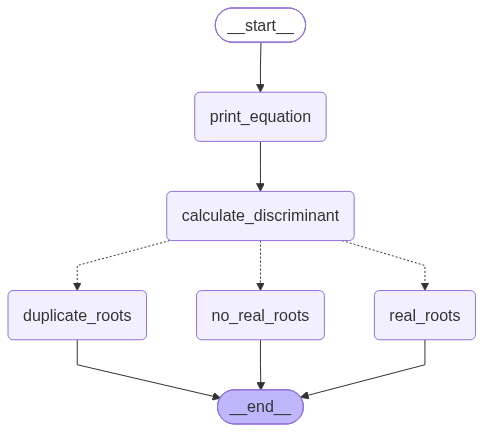

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('print_equation',print_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('duplicate_roots',duplicate_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'print_equation')
graph.add_edge('print_equation','calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('duplicate_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()

In [30]:
intial_state = {'a': 1, 'b': 5, 'c': 6}
final_state = workflow.invoke(intial_state)
print(final_state)

{'a': 1, 'b': 5, 'c': 6, 'equation': '1x^2 + 5x + 6 = 0', 'discriminant': 1, 'result': 'The roots are real and distinct: -2.0 and -3.0'}
